# Titanic Survival Prediction

Dự án phân loại nhị phân trên bộ dữ liệu Kaggle Titanic.

**Cấu trúc thư mục:**

```
├── data/          train.csv, test.csv
├── images/        biểu đồ đánh giá (ROC, confusion matrix, SHAP, ...)
├── reports/       report.docx, slides.pptx (python scripts/build_reports.py)
├── modeling.ipynb
├── model.pkl      pipeline đã train (cho app.py)
├── submission.csv
├── requirements.txt
└── app.py         Streamlit demo
```

**Quy trình:** Import → Load → EDA → Cleaning → FE → Encoding → Split → Train → GridSearch → Evaluation → Plots → Submission → Kết luận

## 1. Import Libraries

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import joblib

try:
    from IPython.display import display
    from IPython import get_ipython
except ImportError:
    display = print

    def get_ipython():
        return None

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TRAIN_PATH = Path("data/train.csv")
TEST_PATH = Path("data/test.csv")
SUBMISSION_PATH = Path("submission.csv")
MODEL_PATH = Path("model.pkl")
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

## 2. Load Dataset

In [2]:
if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Missing {TRAIN_PATH}")
if not TEST_PATH.exists():
    raise FileNotFoundError(f"Missing {TEST_PATH}")

df = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print("Train shape:", df.shape)
print("Test shape:", df_test.shape)
df.head()

Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Basic EDA

Missing values (train):
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survival rate: 0.384


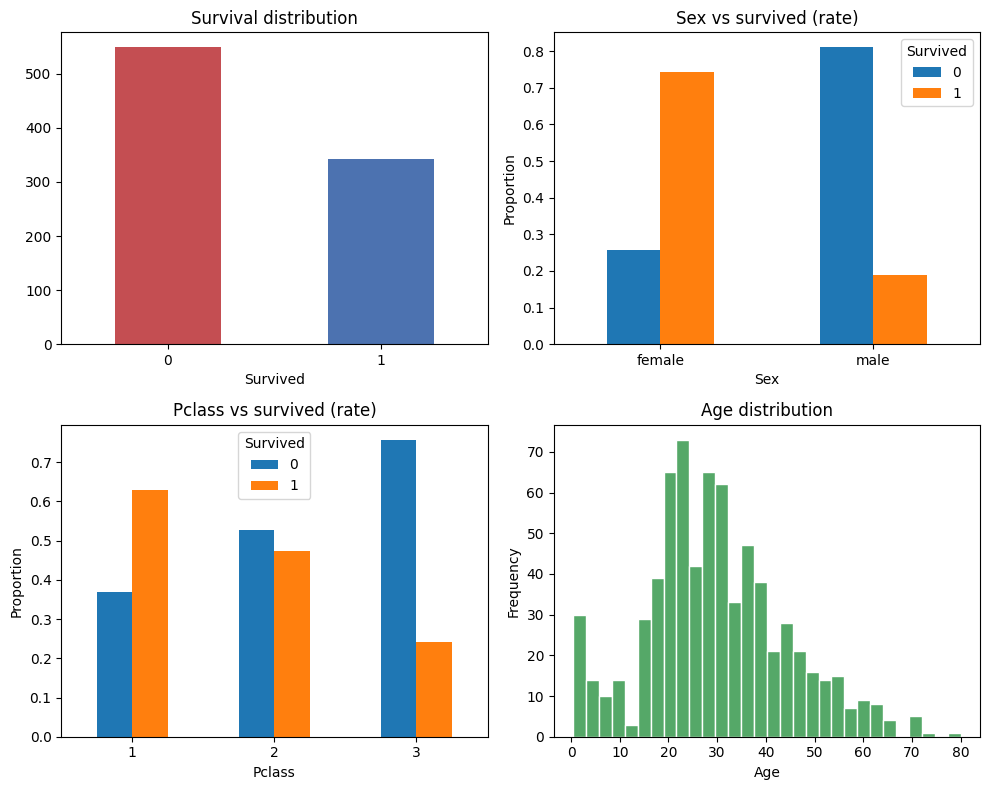

In [3]:
print("Missing values (train):\n", df.isnull().sum())
print("\nSurvival rate:", df["Survived"].mean().round(3))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

df["Survived"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0, 0], color=["#c44e52", "#4c72b0"], rot=0
)
axes[0, 0].set_title("Survival distribution")
axes[0, 0].set_xlabel("Survived")

pd.crosstab(df["Sex"], df["Survived"], normalize="index").plot(
    kind="bar", ax=axes[0, 1], rot=0
)
axes[0, 1].set_title("Sex vs survived (rate)")
axes[0, 1].set_ylabel("Proportion")
axes[0, 1].legend(title="Survived")

pd.crosstab(df["Pclass"], df["Survived"], normalize="index").plot(
    kind="bar", ax=axes[1, 0], rot=0
)
axes[1, 0].set_title("Pclass vs survived (rate)")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].legend(title="Survived")

df["Age"].dropna().plot(kind="hist", bins=30, ax=axes[1, 1], color="#55a868", edgecolor="white")
axes[1, 1].set_title("Age distribution")
axes[1, 1].set_xlabel("Age")

plt.tight_layout()

fig_sr, ax_sr = plt.subplots(figsize=(5, 4))
df["Survived"].value_counts().sort_index().plot(
    kind="bar", ax=ax_sr, color=["#c44e52", "#4c72b0"], rot=0
)
ax_sr.set_title("Survival distribution")
ax_sr.set_xlabel("Survived")
fig_sr.savefig(IMAGES_DIR / "survival_rate.png", dpi=150, bbox_inches="tight")
plt.close(fig_sr)

if get_ipython() is not None:
    plt.show()
else:
    plt.close(fig)

## 4. Data Cleaning

Điền giá trị thiếu (Age theo Title, Embarked mode, Fare median).  
**Lưu ý chống leakage:** `fit()` chỉ trên tập train (bên trong Pipeline sau bước Split).

In [4]:
class TitanicMissingValueImputer(BaseEstimator, TransformerMixin):
    """Age by Title median; Embarked mode; Fare median."""

    def fit(self, X, y=None):
        X_ = pd.DataFrame(X)
        self.age_by_title_ = X_.groupby("Title")["Age"].median()
        self.age_median_ = X_["Age"].median()
        self.embarked_mode_ = X_["Embarked"].mode(dropna=True).iloc[0]
        self.fare_median_ = X_["Fare"].median()
        return self

    def transform(self, X):
        X_ = pd.DataFrame(X).copy()
        for col in ["Age", "Fare", "SibSp", "Parch", "Family_Size", "Group_Size"]:
            if col in X_.columns:
                X_[col] = pd.to_numeric(X_[col], errors="coerce").astype(float)
        for title, med in self.age_by_title_.items():
            mask = X_["Title"].eq(title) & X_["Age"].isna()
            X_.loc[mask, "Age"] = med
        X_["Age"] = X_["Age"].fillna(self.age_median_)
        X_["Embarked"] = X_["Embarked"].fillna(self.embarked_mode_)
        X_["Fare"] = X_["Fare"].fillna(self.fare_median_)
        if "Deck" in X_.columns:
            X_["Deck"] = X_["Deck"].fillna("Unknown")
        return X_

## 5. Feature Engineering

Tạo: **Family_Size**, **Is_Alone**, **Title**, **Deck**, **Group_Size**.

In [5]:
TITLE_MAP = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Rare", "Countess": "Rare", "Col": "Rare", "Don": "Rare",
    "Dr": "Rare", "Major": "Rare", "Rev": "Rare", "Sir": "Rare",
    "Jonkheer": "Rare", "Dona": "Rare", "Capt": "Rare",
}


@dataclass
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    rare_title_min_count: int = 10

    def fit(self, X, y=None):
        X_ = pd.DataFrame(X)
        ticket = X_.get("Ticket", pd.Series(dtype=str))
        self.ticket_counts_ = ticket.fillna("Unknown").astype(str).value_counts()
        titles = self._extract_title(X_)
        vc = titles.value_counts()
        self.common_titles_ = set(vc[vc >= self.rare_title_min_count].index)
        return self

    def transform(self, X):
        X_ = pd.DataFrame(X).copy()
        sibsp = X_.get("SibSp", 0).fillna(0)
        parch = X_.get("Parch", 0).fillna(0)
        X_["Family_Size"] = sibsp + parch + 1
        X_["Is_Alone"] = (X_["Family_Size"] == 1).astype(int)

        title = self._extract_title(X_).replace(TITLE_MAP)
        title = title.where(title.isin(self.common_titles_), "Rare")
        X_["Title"] = title

        cabin = X_.get("Cabin")
        if cabin is None:
            X_["Deck"] = "Unknown"
        else:
            c = cabin.fillna("Unknown").astype(str)
            X_["Deck"] = c.str[0].replace({"U": "Unknown"})
            X_.loc[cabin.isna(), "Deck"] = "Unknown"

        ticket = X_.get("Ticket", pd.Series("Unknown", index=X_.index))
        t = ticket.fillna("Unknown").astype(str)
        X_["Group_Size"] = t.map(self.ticket_counts_).fillna(1).astype(int)

        drop_cols = [c for c in ["PassengerId", "Name", "Cabin", "Ticket", "Survived"] if c in X_.columns]
        return X_.drop(columns=drop_cols)

    @staticmethod
    def _extract_title(X_):
        name = X_.get("Name", pd.Series("", index=X_.index)).fillna("")
        return name.str.extract(r",\s*([^.]+)\.", expand=False).fillna("Unknown")

## 6. Encoding & Preprocessing

Label encode Sex, One-Hot encode categorical, StandardScaler cho numeric (Logistic Regression).

In [6]:
class SexLabelEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.le_ = LabelEncoder()
        self.le_.fit(pd.DataFrame(X)["Sex"])
        return self

    def transform(self, X):
        X_ = pd.DataFrame(X).copy()
        X_["Sex"] = self.le_.transform(X_["Sex"])
        return X_


NUMERIC_FEATURES = ["Age", "SibSp", "Parch", "Fare", "Family_Size", "Is_Alone", "Group_Size", "Sex"]
CATEGORICAL_FEATURES = ["Pclass", "Embarked", "Title", "Deck"]


def make_preprocess(scale_numeric: bool) -> ColumnTransformer:
    num_transformer = StandardScaler() if scale_numeric else "passthrough"
    return ColumnTransformer(
        transformers=[
            ("num", num_transformer, NUMERIC_FEATURES),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )


def make_model_pipeline(estimator, scale_numeric: bool) -> Pipeline:
    return Pipeline(
        steps=[
            ("features", TitanicFeatureEngineer()),
            ("imputer", TitanicMissingValueImputer()),
            ("sex_encode", SexLabelEncoder()),
            ("preprocess", make_preprocess(scale_numeric)),
            ("model", estimator),
        ]
    )

## 7. Train/Test Split

Chia tập **trước** khi `fit` scaler / encoder / model (tránh data leakage).

In [7]:
target_col = "Survived"
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]} | Hold-out test: {X_test.shape[0]}")

Train: 712 | Hold-out test: 179


## 8. Model Training

Ba mô hình: Logistic Regression, Decision Tree, Random Forest (tham số mặc định).

In [8]:
fitted_pipelines = {}

fitted_pipelines["LogisticRegression"] = make_model_pipeline(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), scale_numeric=True
).fit(X_train, y_train)

fitted_pipelines["DecisionTree"] = make_model_pipeline(
    DecisionTreeClassifier(random_state=RANDOM_STATE), scale_numeric=False
).fit(X_train, y_train)

fitted_pipelines["RandomForest"] = make_model_pipeline(
    RandomForestClassifier(random_state=RANDOM_STATE), scale_numeric=False
).fit(X_train, y_train)

print("Trained:", list(fitted_pipelines.keys()))

Trained: ['LogisticRegression', 'DecisionTree', 'RandomForest']


## 9. GridSearchCV

Tinh chỉnh Decision Tree và Random Forest (Logistic Regression giữ mặc định).

In [9]:
GRID_CONFIGS = {
    "DecisionTree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {
            "model__max_depth": [3, 5, 8, None],
            "model__min_samples_split": [2, 10],
        },
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {
            "model__n_estimators": [100, 200],
            "model__max_depth": [4, 6, None],
        },
    ),
}

for name, (estimator, param_grid) in GRID_CONFIGS.items():
    pipe = make_model_pipeline(estimator, scale_numeric=False)
    search = GridSearchCV(pipe, param_grid=param_grid, scoring="f1", cv=5, n_jobs=1)
    search.fit(X_train, y_train)
    fitted_pipelines[name] = search.best_estimator_
    print(f"{name} best params: {search.best_params_}")

rf_pipeline = fitted_pipelines["RandomForest"]

DecisionTree best params: {'model__max_depth': 3, 'model__min_samples_split': 2}
RandomForest best params: {'model__max_depth': 4, 'model__n_estimators': 100}


## 10. Evaluation

Accuracy, Precision, Recall, F1, ROC-AUC trên hold-out test.

In [10]:
def compute_metrics(name: str, pipeline: Pipeline) -> dict:
    proba = pipeline.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
    }


results_df = (
    pd.DataFrame([compute_metrics(n, p) for n, p in fitted_pipelines.items()])
    .sort_values(["f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

print("=== Model comparison (hold-out test) ===")
display(results_df.round(4))

best_name = results_df.iloc[0]["model"]
best_pipe = fitted_pipelines[best_name]
print(f"\nBest model by F1: {best_name}")

=== Model comparison (hold-out test) ===


,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.8436,0.8254,0.7536,0.7879,0.8725
1,DecisionTree,0.8268,0.8065,0.7246,0.7634,0.8502
2,RandomForest,0.8101,0.7778,0.7101,0.7424,0.8449



Best model by F1: LogisticRegression


## 11. ROC Curve, Confusion Matrix & SHAP

- Confusion matrix và ROC: **mô hình tốt nhất** trên hold-out (theo F1).
- Feature importance và SHAP summary: **Random Forest** (giải thích toàn cục).
- Biểu đồ lưu vào `images/`.

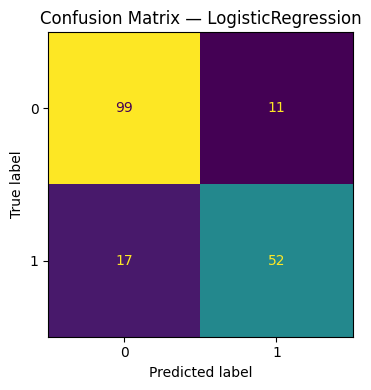

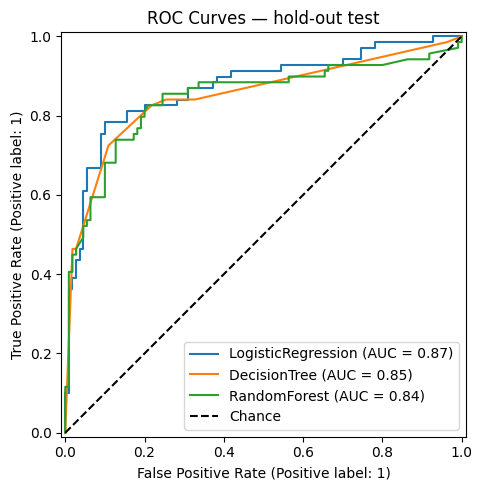

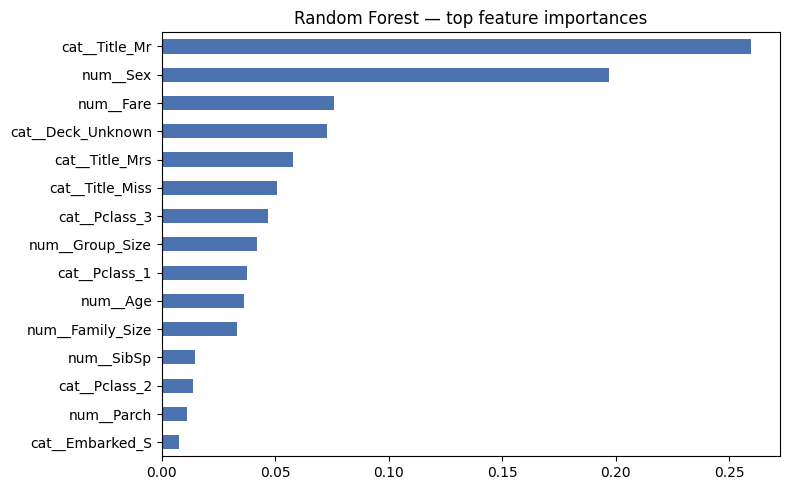

Saved: C:\Python_Project\Do_An_Cuoi_Ki\images\shap_summary.png


<Figure size 1000x600 with 0 Axes>

In [11]:
y_pred_best = best_pipe.predict(X_test)
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best)).plot(
    ax=ax, values_format="d", colorbar=False
)
ax.set_title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
if get_ipython() is not None:
    plt.show()
else:
    plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 5))
for name, pipe in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Chance")
ax.set_title("ROC Curves - hold-out test")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "roc_curve.png", dpi=150, bbox_inches="tight")
if get_ipython() is not None:
    plt.show()
else:
    plt.close(fig)

rf_importances = rf_pipeline.named_steps["model"].feature_importances_
rf_feat_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
imp_series = pd.Series(rf_importances, index=rf_feat_names).sort_values(ascending=True).tail(15)
fig_imp, ax_imp = plt.subplots(figsize=(8, 5))
imp_series.plot(kind="barh", ax=ax_imp, color="#4c72b0")
ax_imp.set_title("Random Forest - top feature importances")
plt.tight_layout()
fig_imp.savefig(IMAGES_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
if get_ipython() is not None:
    plt.show()
else:
    plt.close(fig_imp)

def _transform_for_model(pipeline: Pipeline, X_raw: pd.DataFrame):
    X_fe = pipeline.named_steps["features"].transform(X_raw)
    X_imp = pipeline.named_steps["imputer"].transform(X_fe)
    X_sex = pipeline.named_steps["sex_encode"].transform(X_imp)
    return pipeline.named_steps["preprocess"].transform(X_sex)


SHAP_PLOT_PATH = IMAGES_DIR / "shap_summary.png"
try:
    import shap

    X_test_matrix = _transform_for_model(rf_pipeline, X_test)
    rf_model = rf_pipeline.named_steps["model"]
    feat_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()

    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test_matrix)
    shap_values_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_plot, X_test_matrix, feature_names=feat_names, show=False)
    plt.tight_layout()
    try:
        plt.savefig(SHAP_PLOT_PATH, dpi=200, bbox_inches="tight")
        print(f"Saved: {SHAP_PLOT_PATH.resolve()}")
    except OSError as err:
        print(f"SHAP plot skipped (save error): {err}")
    plt.close()
except ModuleNotFoundError:
    print("Optional: pip install shap for summary plot")

## 12. submission.csv

In [12]:
final_model = clone(best_pipe)
final_model.fit(X, y)

test_preds = final_model.predict(df_test).astype(int)
submission = pd.DataFrame({"PassengerId": df_test["PassengerId"], "Survived": test_preds})
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Saved: {SUBMISSION_PATH.resolve()} ({len(submission)} rows)")
display(submission.head())

try:
    import cloudpickle

    with MODEL_PATH.open("wb") as f:
        cloudpickle.dump(final_model, f)
except ImportError:
    joblib.dump(final_model, MODEL_PATH)
print(f"Saved: {MODEL_PATH.resolve()} (for app.py)")

Saved: C:\Python_Project\Do_An_Cuoi_Ki\submission.csv (418 rows)


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


Saved: C:\Python_Project\Do_An_Cuoi_Ki\model.pkl (for app.py)


## 13. Conclusion

- Đã xây dựng pipeline Titanic với feature engineering có thể giải thích.
- Chia train/test trước khi fit — **không data leakage**.
- So sánh 3 mô hình; GridSearchCV cho Decision Tree và Random Forest.
- Xuất biểu đồ vào `images/` (gồm `shap_summary.png` cho Random Forest).
- File nộp Kaggle: `submission.csv`; pipeline deploy: `model.pkl`.
- Mô hình tốt nhất (theo F1 trên hold-out) được refit trên toàn bộ train cho submission và `app.py`.

Chạy demo (cần `pip install streamlit`): `streamlit run app.py`